## 1 · Imports & configuration

In [27]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(patchwork)   # combiner les plots ggplot2

source("functions_linear.R")

DATASET_PATH <- "/Volumes/My Passport/NEWMOB/clean_dataset.csv"
FPS          <- 30
COLOR_A      <- "#2E86AB"
COLOR_B      <- "#E84855"

theme_set(theme_bw(base_size = 12) +
  theme(panel.grid.minor = element_blank(),
        plot.title = element_text(size = 12)))

✔ Fonctions R chargées : run_linear, run_mixed_linear_panel


## 2 · Chargement du dataset

In [28]:
df_raw <- read.csv(DATASET_PATH, stringsAsFactors = FALSE)
cat(sprintf("Dataset brut : %s lignes x %d colonnes\n",
            format(nrow(df_raw), big.mark = ","), ncol(df_raw)))
cat(sprintf("Trajets      : %d\n", n_distinct(df_raw$source)))
head(df_raw, 4)

Dataset brut : 346,426 lignes x 79 colonnes
Trajets      : 25


,source,frame,speed_kmh,gyrz_deg_s,n_vru_total,n_pedestrians,n_cyclists,n_escooters,prop_vru_pedestrian,prop_vru_cyclist,⋯,mean_ttc_min_s,mean_drac_max_ms2,mean_reaction_time_s,mean_encounter_duration_s,mean_simultaneous_vrus,pct_unknown_interaction,pct_group_size_solo,pct_group_size_pair,pct_group_size_group_3plus,pct_group_size_unknown
,<chr>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,1.88503,1,1,0,0,1,0,⋯,2.548,3.099,NA,2.567,8.148,0,NA,NA,NA,NA
2,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,1.88503,1,1,0,0,1,0,⋯,2.548,3.099,NA,2.567,8.148,0,NA,NA,NA,NA
3,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,1.88503,1,1,0,0,1,0,⋯,2.548,3.099,NA,2.567,8.148,0,NA,NA,NA,NA
4,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,1.88503,1,1,0,0,1,0,⋯,2.548,3.099,NA,2.567,8.148,0,NA,NA,NA,NA


## 3 · Réduction à 1 Hz

Le dataset est échantillonné à 30 FPS. On regroupe par **seconde** (`second = frame %/% 30`) :

In [29]:
df_1hz <- df_raw %>%
  mutate(second = frame %/% FPS) %>%
  group_by(source, second) %>%
  summarise(
    speed_kmh                    = mean(speed_kmh,                        na.rm = TRUE),
    rider_id                     = first(rider_id),
    n_pedestrians                = max(n_pedestrians,                      na.rm = TRUE),
    road_width_perp_m            = mean(road_width_perp_m,                 na.rm = TRUE),
    hour                         = first(hour),
    day_of_week                  = first(day_of_week),
    day_name                     = first(day_name),
    is_weekend                   = first(is_weekend),
    time_of_day                  = first(time_of_day),
    month                        = first(month),
    season                       = first(season),
    genre                        = first(genre),
    age                          = first(age),
    experience                   = first(experience),
    distance_km                  = first(distance_km),
    start_crossing               = max(start_crossing,                     na.rm = TRUE),
    # ── Nouvelles variables annotées ────────────────────────────────────────
    n_elderly                    = max(n_elderly,                          na.rm = TRUE),
   # n_pedestrian_stationnary     = max(n_pedestrian_stationnary,           na.rm = TRUE),
    n_children                   = max(n_children,                         na.rm = TRUE),
    n_running                    = max(n_running,                          na.rm = TRUE),
    n_groups                     = max(n_groups,                           na.rm = TRUE),
    n_crossing                   = max(n_crossing,                         na.rm = TRUE),
    n_pedestrians_crossing       = max(n_pedestrians_crossing,             na.rm = TRUE),
    n_pedestrians_opposite       = max(n_pedestrians_opposite,             na.rm = TRUE),
    n_cyclists_crossing          = max(n_cyclists_crossing,                na.rm = TRUE),
    # ── Variables contextuelles (première valeur disponible) ────────────────
    WEATHER_LABEL                = first(na.omit(WEATHER_LABEL)),
    LIGHTING_LABEL               = first(na.omit(LIGHTING_LABEL)),
    SURFACE_CONDITION_LABEL      = first(na.omit(SURFACE_CONDITION_LABEL)),
    ZONE_TYPE_LABEL              = first(na.omit(ZONE_TYPE_LABEL)),
    VISUAL_SEGREGATION_LABEL     = first(na.omit(VISUAL_SEGREGATION_LABEL)),
    RIDING_COMPANION_LABEL       = first(na.omit(RIDING_COMPANION_LABEL)),
    # ── Cinématique rencontre (résumé trajet — constante par trajet) ─────────
    mean_peak_decel_ms2          = first(mean_peak_decel_ms2),
    mean_ttc_min_s               = first(mean_ttc_min_s),
    mean_drac_max_ms2            = first(mean_drac_max_ms2),
    mean_reaction_time_s         = first(mean_reaction_time_s),
    mean_encounter_duration_s    = first(mean_encounter_duration_s),
    mean_simultaneous_vrus       = first(mean_simultaneous_vrus),
    .groups = "drop"
  ) %>%
  arrange(source, second) %>%
  group_by(source) %>%
  mutate(speed_kmh_t1 = lead(speed_kmh)) %>%
  ungroup()

cat(sprintf("Après réduction 1 Hz : %s secondes — %d trajets\n",
            format(nrow(df_1hz), big.mark = ","),
            n_distinct(df_1hz$source)))
summary(df_1hz)


Après réduction 1 Hz : 1,271 secondes — 25 trajets


    source              second        speed_kmh        rider_id        
 Length:1271        Min.   :  0.0   Min.   : 2.018   Length:1271       
 Class :character   1st Qu.: 15.5   1st Qu.: 9.293   Class :character  
 Mode  :character   Median : 39.0   Median :12.134   Mode  :character  
                    Mean   : 52.5   Mean   :14.854                     
                    3rd Qu.: 77.0   3rd Qu.:20.706                     
                    Max.   :202.0   Max.   :33.850                     
                                    NA's   :29                         
 n_pedestrians    road_width_perp_m       hour        day_of_week   
 Min.   : 0.000   Min.   :  0.0371   Min.   : 5.00   Min.   :0.000  
 1st Qu.: 1.000   1st Qu.:  8.0393   1st Qu.: 6.00   1st Qu.:2.000  
 Median : 3.000   Median : 11.0491   Median :10.00   Median :3.000  
 Mean   : 3.395   Mean   : 16.5326   Mean   :10.66   Mean   :3.152  
 3rd Qu.: 5.000   3rd Qu.: 22.6169   3rd Qu.:13.00   3rd Qu.:4.000  
 Max.   :1

## 4 · Variable dépendante : `speed_kmh_t1`

Observations totales : 1,210
  Vitesse moyenne : 14.96 km/h
  Vitesse médiane : 12.18 km/h
  Écart-type      : 7.54 km/h
  Min / Max       : 2.36 / 33.85 km/h


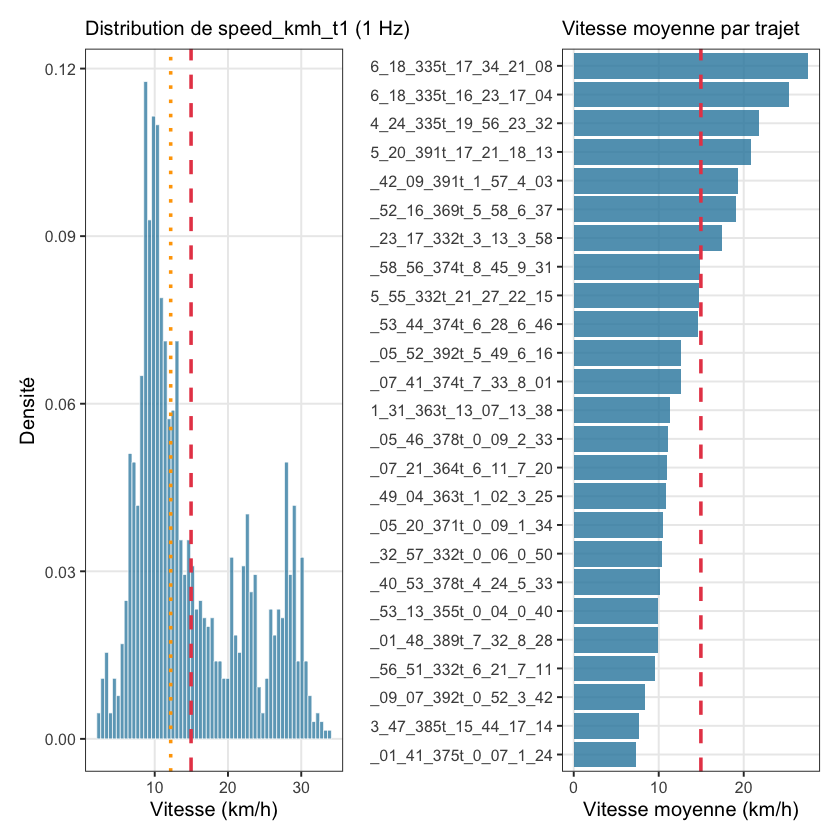

In [30]:
df_model <- df_1hz %>%
  filter(!is.na(speed_kmh_t1), !is.na(n_pedestrians), !is.na(road_width_perp_m)) %>%
  mutate(rider_id_num = as.integer(factor(rider_id)))

cat(sprintf("Observations totales : %s\n", format(nrow(df_model), big.mark = ",")))
cat(sprintf("  Vitesse moyenne : %.2f km/h\n", mean(df_model$speed_kmh_t1)))
cat(sprintf("  Vitesse médiane : %.2f km/h\n", median(df_model$speed_kmh_t1)))
cat(sprintf("  Écart-type      : %.2f km/h\n", sd(df_model$speed_kmh_t1)))
cat(sprintf("  Min / Max       : %.2f / %.2f km/h\n",
            min(df_model$speed_kmh_t1), max(df_model$speed_kmh_t1)))

p1 <- ggplot(df_model, aes(x = speed_kmh_t1)) +
  geom_histogram(aes(y = after_stat(density)), bins = 60,
                 fill = COLOR_A, alpha = 0.75, color = "white", linewidth = 0.2) +
  geom_vline(aes(xintercept = mean(speed_kmh_t1)), color = COLOR_B,
             linetype = "dashed", linewidth = 1) +
  geom_vline(aes(xintercept = median(speed_kmh_t1)), color = "orange",
             linetype = "dotted", linewidth = 1) +
  labs(x = "Vitesse (km/h)", y = "Densité",
       title = "Distribution de speed_kmh_t1 (1 Hz)")

speed_by_traj <- df_model %>%
  group_by(source) %>%
  summarise(mean_speed = mean(speed_kmh_t1), .groups = "drop") %>%
  arrange(mean_speed) %>%
  mutate(source_short = substr(source, nchar(source) - 20, nchar(source)))

p2 <- ggplot(speed_by_traj, aes(x = mean_speed, y = reorder(source_short, mean_speed))) +
  geom_col(fill = COLOR_A, alpha = 0.8) +
  geom_vline(xintercept = mean(df_model$speed_kmh_t1),
             color = COLOR_B, linetype = "dashed", linewidth = 1) +
  labs(x = "Vitesse moyenne (km/h)", y = NULL, title = "Vitesse moyenne par trajet")

p1 + p2

## 5 · Standardisation & création de dummies

In [31]:
# ── Regrouper Evening et Night en une seule catégorie ────────────────────────
df_model <- df_model %>%
  mutate(time_of_day = ifelse(time_of_day %in% c("Night", "Evening"), "Night", as.character(time_of_day)))

cat("Distribution time_of_day après regroupement :\n")
print(table(df_model$time_of_day))

Distribution time_of_day après regroupement :

Afternoon   Morning     Night 
      449       729        32 


In [ ]:
# ── Variables continues à standardiser ───────────────────────────────────────
cont_vars <- c(
  # variables existantes
  "n_pedestrians", "road_width_perp_m", "hour", "age", "distance_km",
  # nouvelles variables annotées (comptages VRU)
  "n_elderly", "n_children", "n_running", "n_groups",
  "n_crossing", "n_pedestrians_crossing", "n_pedestrians_opposite", "n_cyclists_crossing",
  # cinématique rencontre (résumé trajet)
  "mean_peak_decel_ms2", "mean_ttc_min_s", "mean_drac_max_ms2",
  "mean_reaction_time_s", "mean_encounter_duration_s", "mean_simultaneous_vrus"
)
cont_vars <- cont_vars[cont_vars %in% names(df_model)]

# Stocker moyennes et écarts-types pour les effets marginaux
means_ <- sapply(cont_vars, function(v) mean(df_model[[v]], na.rm = TRUE))
stds_  <- sapply(cont_vars, function(v) sd(df_model[[v]],   na.rm = TRUE))

for (v in cont_vars) {
  if (!is.na(stds_[v]) && stds_[v] != 0) {
    df_model[[paste0("z_", v)]] <- (df_model[[v]] - means_[v]) / stds_[v]
  } else {
    df_model[[paste0("z_", v)]] <- 0
    warning(sprintf("  %s a un écart-type nul", v))
  }
}

cat("Statistiques des z-scores :\n")
z_cols <- paste0("z_", cont_vars)
print(summary(df_model[, z_cols[z_cols %in% names(df_model)]]))

# ── Variables catégorielles ───────────────────────────────────────────────────
set_ref <- function(df, col) {
  ref <- names(sort(table(df[[col]]), decreasing = TRUE))[1]
  df[[col]] <- relevel(factor(df[[col]]), ref = ref)
  df
}

cat_vars <- c(
  # variables existantes
  "rider_id", "day_of_week", "day_name", "is_weekend",
  "time_of_day", "month", "season", "genre", "experience", "start_crossing",
  # intersection
  "at_intersection",
  # variables contextuelles annotées
  "WEATHER_LABEL", "LIGHTING_LABEL", "SURFACE_CONDITION_LABEL",
  "ZONE_TYPE_LABEL", "VISUAL_SEGREGATION_LABEL", "RIDING_COMPANION_LABEL"
)
cat_vars <- cat_vars[cat_vars %in% names(df_model)]

for (v in cat_vars) {
  df_model <- set_ref(df_model, v)
  cat(sprintf("  %-35s → %d niveaux  (réf = '%s')\n",
              v, nlevels(df_model[[v]]),
              levels(df_model[[v]])[1]))
}

## 6 · Modèles

### Modèle 0 — Constante seule

`speed_kmh_t1 = MU + epsilon`

In [9]:
all_results <- list()

r0 <- run_linear(df_model, "1", "M0_null")
all_results[["M0_null"]] <- r0$metrics


  Modèle cst      : LL=-4160.74
  Modèle principal: N=1210  K=2  LL=-4160.74
  rho²=0.0000  AIC=8325.5  BIC=8335.7
  LRT vs cst : chi²(0)=-0.00  p=NA (n.s.)
            Estimate Std. Error  t value Pr(>|t|)
(Intercept) 14.96044  0.2167335 69.02691        0


### Modèle 1 — Piétons

`speed_kmh_t1 = MU + beta_ped * z_n_pedestrians + epsilon`

**Hypothèse :** plus il y a de piétons, plus la vitesse est réduite (beta attendu négatif).

In [10]:
r1 <- run_linear(df_model, "z_n_pedestrians", "M1_pedestrians", ref = r0)
all_results[["M1_pedestrians"]] <- r1$metrics


  Modèle cst      : LL=-4160.74
  Modèle principal: N=1210  K=3  LL=-4019.51
  rho²=0.0339  AIC=8045.0  BIC=8060.3
  LRT vs cst : chi²(1)=282.45  p=0.0000 ***
                 Estimate Std. Error   t value     Pr(>|t|)
(Intercept)     14.960444  0.1929378  77.54025 0.000000e+00
z_n_pedestrians -3.439892  0.1930175 -17.82165 2.941334e-63


### Modèle 2 — Piétons + Largeur de route

In [11]:
r2 <- run_linear(df_model,
                 "z_n_pedestrians + z_road_width_perp_m",
                 "M2_ped_width", ref = r0)
all_results[["M2_ped_width"]] <- r2$metrics


  Modèle cst      : LL=-4160.74
  Modèle principal: N=1210  K=4  LL=-4019.12
  rho²=0.0340  AIC=8046.2  BIC=8066.6
  LRT vs cst : chi²(2)=283.25  p=0.0000 ***
                      Estimate Std. Error     t value     Pr(>|t|)
(Intercept)         14.9604440  0.1929544  77.5335803 0.000000e+00
z_n_pedestrians     -3.3857990  0.2023769 -16.7301648 1.149941e-56
z_road_width_perp_m -0.1801106  0.2023769  -0.8899758 3.736562e-01


### Modèle 3 — Piétons + Genre + Expérience + Moment de la journée + Âge

In [12]:
r3 <- run_linear(df_model,
                 "z_n_pedestrians + genre + experience + time_of_day + z_age",
                 "M3_ped_genre_exp", ref = r0)
all_results[["M3_ped_genre_exp"]] <- r3$metrics


  Modèle cst      : LL=-4160.74
  Modèle principal: N=1210  K=10  LL=-3653.79
  rho²=0.1218  AIC=7327.6  BIC=7378.6
  LRT vs cst : chi²(8)=1013.90  p=0.0000 ***
                       Estimate Std. Error   t value      Pr(>|t|)
(Intercept)          13.1871760  0.2826787 46.650762 6.566064e-272
z_n_pedestrians      -0.9187388  0.1744165 -5.267499  1.637725e-07
genremale             5.8022011  0.3285991 17.657385  3.260806e-62
experience<0.5       -1.1313317  0.3564031 -3.174304  1.540112e-03
experience0.5-1      -3.3531693  1.3285484 -2.523935  1.173305e-02
experience1-2         2.6679133  0.5566163  4.793092  1.847627e-06
time_of_dayAfternoon -3.0777400  0.3336245 -9.225163  1.236371e-19
time_of_dayNight      5.1603365  1.2739170  4.050763  5.432631e-05
z_age                 2.8225674  0.1669247 16.909228  1.059539e-57


### Modèle 4 — Mixte panel (intercept aléatoire par rider)

In [37]:
r4 <- run_mixed_linear_panel(
  df_model,
  rhs          = " genre + z_n_elderly + z_n_pedestrians_opposite + z_n_pedestrians_crossing + z_n_running + z_hour + z_n_pedestrians + z_road_width_perp_m",
  model_name   = "M4_mixed",
  panel_id_col = "rider_id"
)
all_results[["M4_mixed"]] <- r4$metrics

# Effets aléatoires
cat(sprintf("sigma_rider = %.4f km/h\n", r4$metrics$sigma_rider))
cat(sprintf("sigma_eps   = %.4f km/h\n", r4$metrics$sigma_eps))
cat(sprintf("ICC         = %.4f\n",       r4$metrics$ICC))


  Mixed panel linear model: M4_mixed
  Riders=16  Observations=1210
  sigma_rider=4.1978  sigma_eps=3.6022
  Modèle nul      : LL=-3329.64
  Modèle principal: K=11  LL=-3301.80
  rho²=0.0084  AIC=6625.6  BIC=6681.7
  LRT vs nul : chi²(8)=55.70  p=0.0000 ***
                            Estimate Std. Error         df    t value
(Intercept)              10.91488264  1.5060284   16.18301  7.2474613
genremale                 4.82667018  2.1257500   16.06920  2.2705728
z_n_elderly               0.30295963  0.1203709 1200.62597  2.5168850
z_n_pedestrians_opposite  0.18436544  0.1765545 1198.04094  1.0442411
z_n_pedestrians_crossing  0.08884754  0.1343646 1201.94751  0.6612422
z_n_running               0.72294899  0.1653543 1209.03553  4.3721221
z_hour                   -1.06061806  0.3257571  972.55835 -3.2558554
z_n_pedestrians          -0.56961862  0.2159574 1204.15169 -2.6376440
z_road_width_perp_m       0.36752163  0.1374680 1208.92001  2.6735066
                             Pr(>|t|)
(In

## 7 · Comparaison des modèles

In [14]:
comparison <- bind_rows(all_results) %>%
  mutate(Model = names(all_results)) %>%
  select(Model, N, K, LL_null, LL_final, rho2, rho2_bar, AIC, BIC,
         LRT_stat, LRT_df, LRT_p, sigma_rider, sigma_eps, ICC)

knitr::kable(comparison, digits = 4, format.args = list(big.mark = ","))



|Model            |     N|  K|   LL_null|  LL_final|   rho2| rho2_bar|      AIC|      BIC| LRT_stat| LRT_df| LRT_p| sigma_rider| sigma_eps|    ICC|
|:----------------|-----:|--:|---------:|---------:|------:|--------:|--------:|--------:|--------:|------:|-----:|-----------:|---------:|------:|
|M0_null          | 1,210|  2| -4,160.74| -4,160.74| 0.0000|  -0.0005| 8,325.48| 8,335.67|     0.00|      0|    NA|          NA|        NA|     NA|
|M1_pedestrians   | 1,210|  3| -4,160.74| -4,019.51| 0.0339|   0.0332| 8,045.03| 8,060.32|   282.45|      1|     0|          NA|        NA|     NA|
|M2_ped_width     | 1,210|  4| -4,160.74| -4,019.12| 0.0340|   0.0331| 8,046.23| 8,066.63|   283.25|      2|     0|          NA|        NA|     NA|
|M3_ped_genre_exp | 1,210| 10| -4,160.74| -3,653.79| 0.1218|   0.1194| 7,327.58| 7,378.57| 1,013.90|      8|     0|          NA|        NA|     NA|
|M4_mixed         | 1,210| 10| -3,329.64| -3,298.91| 0.0092|   0.0062| 6,617.83| 6,668.81|    61.46|      7|  

In [15]:
# LR-tests emboîtés
lr_test <- function(res_r, res_f) {
  ll_r <- res_r$metrics$LL_final
  ll_f <- res_f$metrics$LL_final
  k_r  <- res_r$metrics$K
  k_f  <- res_f$metrics$K
  lr   <- -2 * (ll_r - ll_f)
  dk   <- k_f - k_r
  p    <- if (dk > 0) pchisq(lr, df = dk, lower.tail = FALSE) else NA
  c(LR = round(lr, 2), delta_k = dk, p = round(p, 4))
}

cat("\nLR-tests (modèles emboîtés) :\n")
cat(sprintf("  M0 → M1 : %s\n", paste(lr_test(r0, r1), collapse = "  ")))
cat(sprintf("  M1 → M2 : %s\n", paste(lr_test(r1, r2), collapse = "  ")))
cat(sprintf("  M2 → M3 : %s\n", paste(lr_test(r2, r3), collapse = "  ")))
cat(sprintf("  M3 → M4 : %s\n", paste(lr_test(r3, r4), collapse = "  ")))


LR-tests (modèles emboîtés) :
  M0 → M1 : 282.46  1  0
  M1 → M2 : 0.78  1  0.3771
  M2 → M3 : 730.66  6  0
  M3 → M4 : 709.76  0  NA


## 8 · Effets marginaux (M3)

Pour un modèle **linéaire**, l'effet marginal = coefficient / écart-type de la variable originale.

Effets marginaux — M3 :
           Variable beta_z (km/h/σ) ME (km/h/unité)     Unité
1     n_pedestrians         -0.9187        -0.32832 piéton(s)
2 road_width_perp_m              NA              NA  mètre(s)
3               age          2.8226         0.22542     an(s)


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_col()`).”


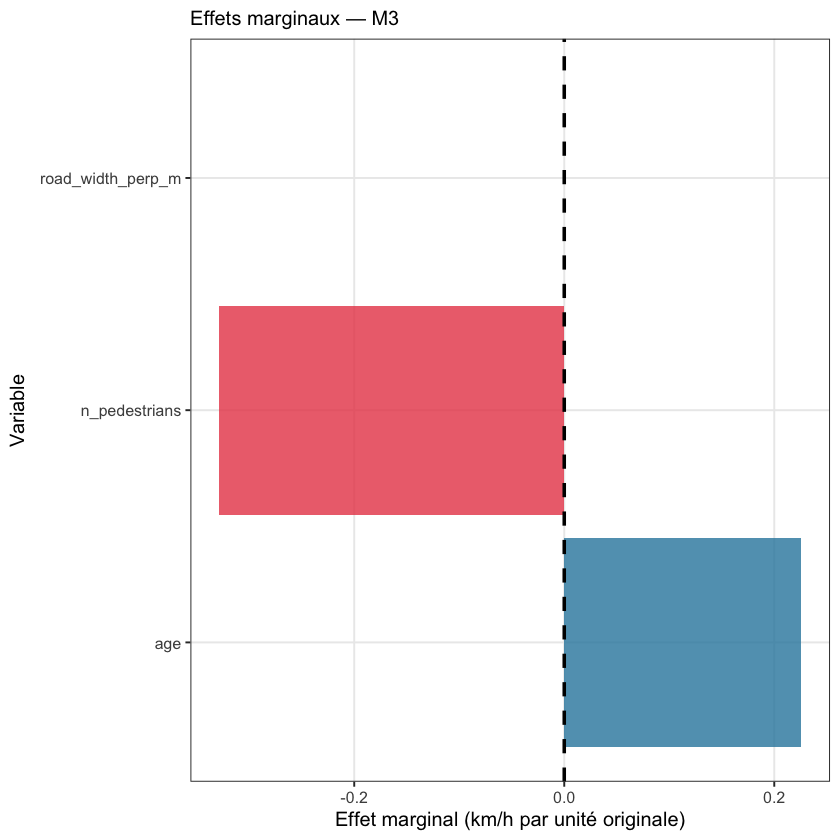

In [16]:
coefs <- coef(r3$fit)
mu_val <- coefs["(Intercept)"]

var_map <- list(
  list(beta = "z_n_pedestrians",  raw = "n_pedestrians",    unit = "piéton(s)"),
  list(beta = "z_road_width_perp_m", raw = "road_width_perp_m", unit = "mètre(s)"),
  list(beta = "z_age",            raw = "age",              unit = "an(s)")
)

me_rows <- lapply(var_map, function(x) {
  beta_z      <- unname(coefs[x$beta])
  sd_raw      <- unname(stds_[x$raw])
  me_per_unit <- if (!is.na(beta_z) && !is.na(sd_raw)) beta_z / sd_raw else NA_real_
  data.frame(Variable          = x$raw,
             `beta_z (km/h/σ)` = round(beta_z, 4),
             `ME (km/h/unité)` = round(me_per_unit, 5),
             Unité              = x$unit,
             check.names = FALSE)
})

me_df <- bind_rows(me_rows)
cat("Effets marginaux — M3 :\n")
print(me_df)

ggplot(me_df, aes(x = `ME (km/h/unité)`, y = Variable,
                  fill = `ME (km/h/unité)` >= 0)) +
  geom_col(alpha = 0.8) +
  scale_fill_manual(values = c("TRUE" = COLOR_A, "FALSE" = COLOR_B), guide = "none") +
  geom_vline(xintercept = 0, linetype = "dashed", linewidth = 1) +
  labs(x = "Effet marginal (km/h par unité originale)",
       title = "Effets marginaux — M3") +
  theme(legend.position = "none")

## 9 · Courbes de prédiction (M3)

Chaque graphique fait varier **une variable** sur son étendue (p2–p98),
toutes les autres maintenues à leur moyenne (z = 0).

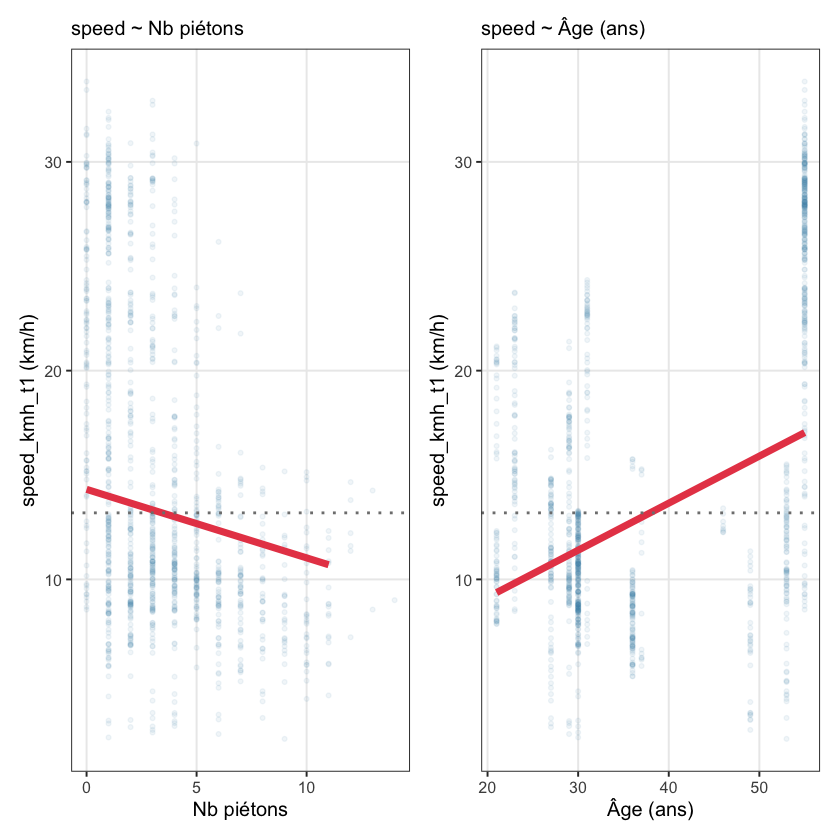

In [17]:
vars_plot <- list(
  list(beta = "z_n_pedestrians",  raw = "n_pedestrians",    label = "Nb piétons"),
  list(beta = "z_road_width_perp_m", raw = "road_width_perp_m", label = "Largeur route (m)"),
  list(beta = "z_age",            raw = "age",              label = "Âge (ans)")
)

plots_pred <- lapply(vars_plot, function(v) {
  if (!(v$raw %in% names(df_model))) return(NULL)
  beta_val <- coefs[v$beta]
  if (is.na(beta_val)) return(NULL)

  x_raw <- seq(quantile(df_model[[v$raw]], 0.02, na.rm = TRUE),
               quantile(df_model[[v$raw]], 0.98, na.rm = TRUE),
               length.out = 200)
  x_z    <- (x_raw - means_[v$raw]) / stds_[v$raw]
  y_pred <- mu_val + beta_val * x_z

  pred_df  <- data.frame(x = x_raw, y = y_pred)
  obs_df   <- df_model[, c(v$raw, "speed_kmh_t1")] %>%
              rename(x = 1, y = speed_kmh_t1) %>%
              filter(!is.na(x), !is.na(y))

  ggplot() +
    geom_point(data = obs_df,  aes(x = x, y = y),
               alpha = 0.07, size = 1, color = COLOR_A) +
    geom_line(data  = pred_df, aes(x = x, y = y),
              color = COLOR_B, linewidth = 2) +
    geom_hline(yintercept = mu_val, linetype = "dotted",
               color = "gray50", linewidth = 0.8) +
    labs(x = v$label, y = "speed_kmh_t1 (km/h)",
         title = paste("speed ~", v$label))
})

plots_pred <- Filter(Negate(is.null), plots_pred)
wrap_plots(plots_pred, nrow = 1)

## 10 · Diagnostic des résidus (M3)

R² (OLS) — M3 : 0.5674
RMSE — M3      : 4.957 km/h

Test Shapiro-Wilk (n=1210) : stat=0.9806, p=1.2195e-11


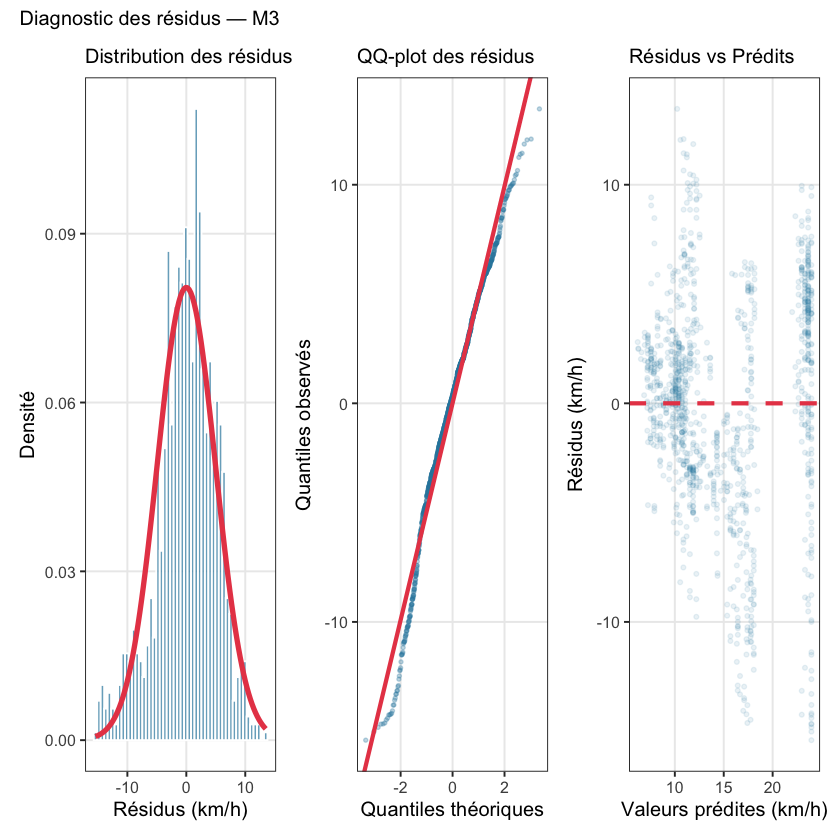

In [18]:
data_m3 <- df_model %>%
  select(speed_kmh_t1, z_n_pedestrians, z_road_width_perp_m, z_age,
         genre, experience, time_of_day) %>%
  filter(complete.cases(.))

y_pred_m3 <- predict(r3$fit, newdata = data_m3)
residuals  <- data_m3$speed_kmh_t1 - y_pred_m3

ss_res <- sum(residuals^2)
ss_tot <- sum((data_m3$speed_kmh_t1 - mean(data_m3$speed_kmh_t1))^2)
r2_ols <- 1 - ss_res / ss_tot
rmse   <- sqrt(mean(residuals^2))

cat(sprintf("R² (OLS) — M3 : %.4f\n", r2_ols))
cat(sprintf("RMSE — M3      : %.3f km/h\n", rmse))

resid_df <- data.frame(y_pred = y_pred_m3, resid = residuals)

# 1. Distribution des résidus
p_hist <- ggplot(resid_df, aes(x = resid)) +
  geom_histogram(aes(y = after_stat(density)), bins = 50,
                 fill = COLOR_A, alpha = 0.7, color = "white") +
  stat_function(fun = dnorm, args = list(mean = 0, sd = sd(residuals)),
                color = COLOR_B, linewidth = 1.5) +
  labs(x = "Résidus (km/h)", y = "Densité", title = "Distribution des résidus")

# 2. QQ-plot
qq_data <- data.frame(
  sample    = sort(residuals),
  theorical = qnorm(ppoints(length(residuals)))
)
p_qq <- ggplot(qq_data, aes(x = theorical, y = sample)) +
  geom_point(alpha = 0.3, size = 0.8, color = COLOR_A) +
  geom_abline(slope = sd(residuals), intercept = 0,
              color = COLOR_B, linewidth = 1.2) +
  labs(x = "Quantiles théoriques", y = "Quantiles observés",
       title = "QQ-plot des résidus")

# 3. Résidus vs valeurs prédites
p_rv <- ggplot(resid_df, aes(x = y_pred, y = resid)) +
  geom_point(alpha = 0.1, size = 1, color = COLOR_A) +
  geom_hline(yintercept = 0, color = COLOR_B, linetype = "dashed", linewidth = 1.2) +
  labs(x = "Valeurs prédites (km/h)", y = "Résidus (km/h)",
       title = "Résidus vs Prédits")

(p_hist | p_qq | p_rv) +
  plot_annotation(title = "Diagnostic des résidus — M3")

# Test de normalité Shapiro-Wilk (sous-échantillon)
n_test   <- min(5000, length(residuals))
sw_result <- shapiro.test(sample(residuals, n_test))
cat(sprintf("\nTest Shapiro-Wilk (n=%d) : stat=%.4f, p=%.4e\n",
            n_test, sw_result$statistic, sw_result$p.value))

## 11 · Visualisation comparaison des modèles

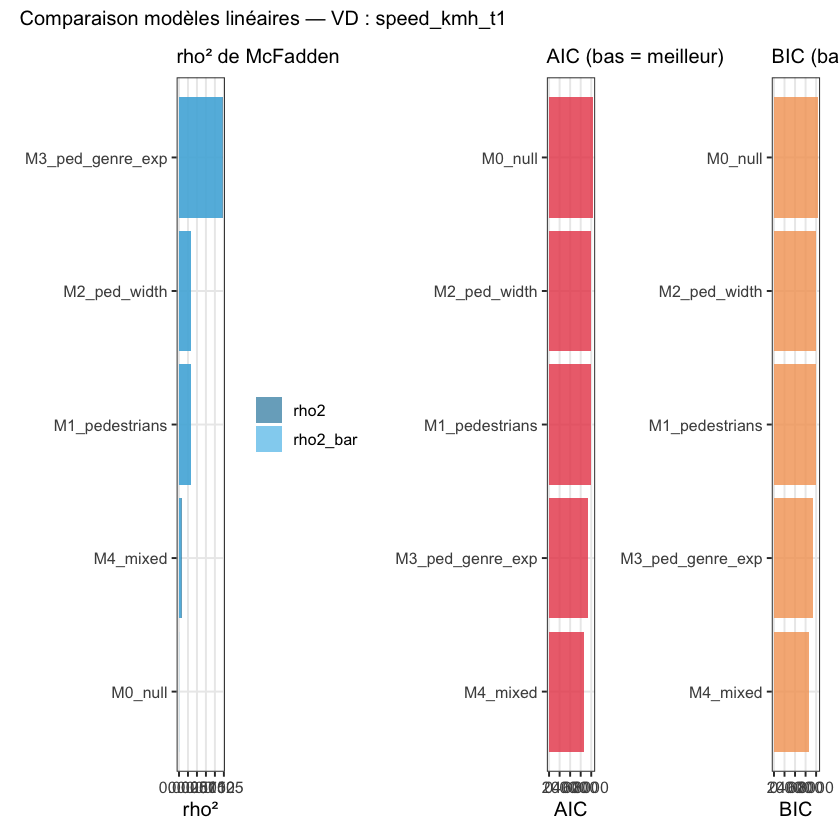

In [19]:
comp_long <- comparison %>%
  select(Model, rho2, rho2_bar, AIC, BIC) %>%
  pivot_longer(-Model, names_to = "metric", values_to = "value")

p_rho <- comparison %>%
  select(Model, rho2, rho2_bar) %>%
  pivot_longer(-Model) %>%
  ggplot(aes(x = reorder(Model, value), y = value, fill = name)) +
  geom_col(position = "identity", alpha = 0.7) +
  scale_fill_manual(values = c("rho2" = COLOR_A, "rho2_bar" = "#5BC0EB")) +
  coord_flip() +
  labs(x = NULL, y = "rho²", title = "rho² de McFadden", fill = NULL)

p_aic <- ggplot(comparison, aes(x = reorder(Model, AIC), y = AIC)) +
  geom_col(fill = COLOR_B, alpha = 0.8) +
  coord_flip() +
  labs(x = NULL, y = "AIC", title = "AIC (bas = meilleur)")

p_bic <- ggplot(comparison, aes(x = reorder(Model, BIC), y = BIC)) +
  geom_col(fill = "#F4A261", alpha = 0.8) +
  coord_flip() +
  labs(x = NULL, y = "BIC", title = "BIC (bas = meilleur)")

(p_rho | p_aic | p_bic) +
  plot_annotation(title = "Comparaison modèles linéaires — VD : speed_kmh_t1")

## 12 · Synthèse
